In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#There are various situations where the missing alue handling is required.
#Any ML model is not capable of handling a null value by default.

#There are mainly two ways to handle missing data....

In [5]:
#The first way is to remove the wjole row that contains anyhy missing data...
#It is often not considerd optimal as when there are a numerous number of rows with some missing values...
#we end up removing the entire row that leads to anomalous behavious of an ML engine...

In [6]:
#The second way is to impute them
#IMPUTE = Filling the missing values rather than deleting the entore rows...

#There are two main ways of imputing data...

#Univariate - Focusing on only one column at a time. This is also called simple imputer

#-->int - mean,median,random_value,end of distribution
#-->categorical - mode,missing value

#Multivariate - Focusing on multiple columns at a time

#->KNN imputer Class
#->Iterative Imputer Class - MICE ALgo

In [7]:
# METHOD 1

#It is also caled CCA(Complete Case Analysis)
#Called list-wise deletion
#In simple terms, it is observation of rows when anyof those fulfill all fetures.

#Assumption for CCA-

#Data is completely missing at random....if the mising in a pattern like in the stsrt or in the end...
#we do not do CCA.--MCAR(Missing COmpletely at Random
#In general, not more than 5% of data should be missing.

In [8]:
df=pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [9]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
#Now, gender has 23% null data, so according to rules, we cannot remove all null rows...
#We can remove rows according to columns like city_development_index and training_hours as they are <=5%...

In [11]:
col = [var for var in df.columns if df[var].isnull().mean()<=0.05 and df[var].isnull().mean()>0]

In [12]:
df[col].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
433,0.884,Part time course,Graduate,5.0,16.0
10564,0.924,no_enrollment,Masters,16.0,74.0
14596,0.926,no_enrollment,Graduate,19.0,13.0
1268,0.558,Part time course,Graduate,2.0,NaN
18009,0.925,Full time course,Graduate,2.0,68.0


In [13]:
dfnew=df[col].dropna()
dfnew.head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0


In [14]:
#Whenever we apply CCA to numerical tables, always check the histogram after CCA...If it matches in terms of before and after..
#Then the CCA is a success or else, it has changes the actual meaning of the data...

<Axes: xlabel='training_hours', ylabel='Count'>

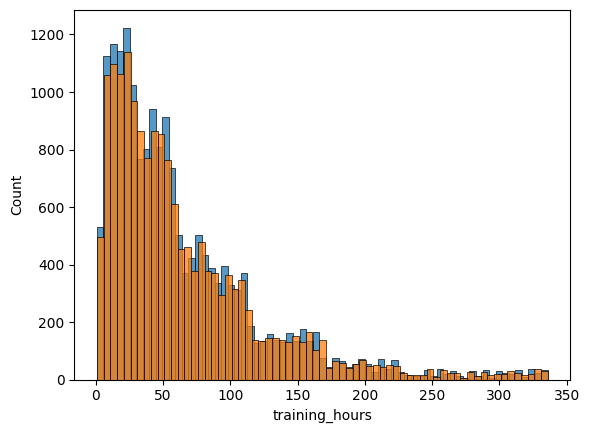

In [15]:
sns.histplot(df['training_hours'])
sns.histplot(dfnew['training_hours'])

In [16]:
#This is a small dataset, so we can consider only one feature....
#CLearly,w e can see that the two histoghrams are almost similar...and hence, the CCA is a success...

In [17]:
#IMPUTER

#Used even if data in not random

#Numeric - Mean or Median in case of numerical...Summetric displot - Mean...Asymmetric displot - Median
#Categorical or numerical categorical - Mode

#After applying an IMPUTERm the variance of the dataset drops....this is a result....
#But this process makes it troublesome for features with correlation and influence due to the decrese in Variance...
#To solve this, The KNN imputer is used if the variance drops drastically...

In [18]:
#RANDOM SAMPLE IMPUTER

#In this type of imputer, we see which values are missing and then, we fill them by random values that are present in other rows of the 
#same feature...
#This technique follows for both, numeric and categorical...

# The biggest benefit is that it is very easy to apply...it is done using pandas....
#Also, the Variancein after this process stays intact...

#Since this introduces randomness, it is not optimal for tree based algos like random forest,etc...
#It is only optimal for linear algos...
#The correlation metric of the data is a bit hampered after this process
#Also, if we deplot this on the cloud, and the new data row contains a null value, we will need to refer back to the training dataset ans
#hence, there is a need to store this on the cloud...consuming more space...

In [22]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','2urvived'])
df.head()

,Age,Fare,2urvived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [24]:
df.isnull().sum()

Age         0
Fare        0
2urvived    0
dtype: int64

In [56]:
# Sample dataframe with some missing Age values
df = pd.DataFrame({
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Age': [22, 35, np.nan, 40, 28, np.nan, 30, 25]
})

print(df)

  Name   Age
0    A  22.0
1    B  35.0
2    C   NaN
3    D  40.0
4    E  28.0
5    F   NaN
6    G  30.0
7    H  25.0


In [57]:
dfnew=df.copy() # We do not modify the original table whwnver handling missing values....this is because if in case, the older version contained 
#some sort of opattern we never thought about, that would be lost...

count = dfnew['Age'].isnull().sum()
dfnew['Age'].isnull().sum()

np.int64(2)

In [58]:
random_sample = dfnew['Age'].dropna().sample(n=count,random_state=42)
random_sample

0    22.0
1    35.0
Name: Age, dtype: float64

In [59]:
#Putting on indexes to the missing imputer values...

random_sample.index = dfnew[dfnew['Age'].isnull()].index
random_sample.index

dfnew.loc[dfnew['Age'].isnull(), 'Age'] = random_sample

In [60]:
dfnew

,Name,Age
0,A,22.0
1,B,35.0
2,C,22.0
3,D,40.0
4,E,28.0
5,F,35.0
6,G,30.0
7,H,25.0


In [61]:
df.describe()

,Age
count,6.00000
mean,30.00000
std,6.60303
min,22.00000
25%,25.75000
50%,29.00000
75%,33.75000
max,40.00000


In [64]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [65]:
df.describe()

,Age
count,8.000000
mean,30.000000
std,5.580579
min,22.000000
25%,27.250000
50%,30.000000
75%,31.250000
max,40.000000


In [66]:
dfnew.describe()

,Age
count,8.000000
mean,29.625000
std,6.610327
min,22.000000
25%,24.250000
50%,29.000000
75%,35.000000
max,40.000000


In [68]:
#KNN Imputer

#KNN imputer is based on KNN algo simply...
#It simply tells that the missing value of a row is simply dependent on its neighbouring datapoints...
#It is based on the principle of euclidian distance...

#It will simly work when there is only one missing value in a row...It won't be optimal for multiple mising values....
#When we talk of scenerios where there is multiple no. of missing vakues in a row...
#The correct approach is to call it, "NAN_Euclidian_Distance"...

#This formula handles the multiple missing values by considering only those values that are present in the row...

#In case of NAN, there is a term multiplied inside the square root while findin the distance..
#The term is simply "Total Number of features / Available number of features"

#SO in cases where there are all values present in the null value row...total no. of rows  = available no. of rows...so the firmula stays the same...